In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import urllib.request
import csv
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

Events loaded  : 500000
Events skipped : 0


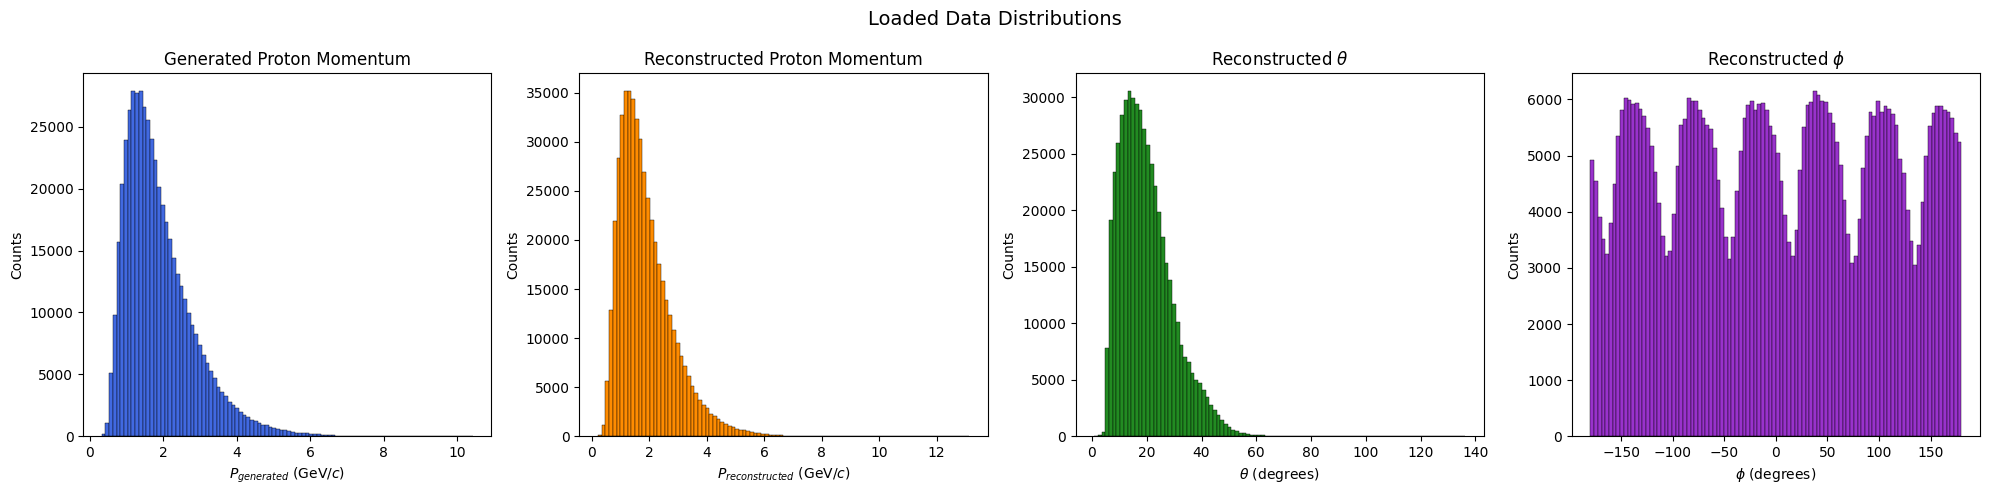

Saved csv_input_distributions.png


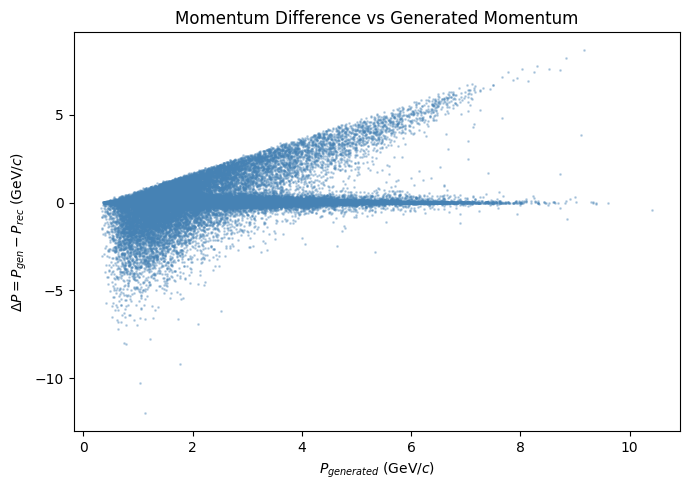

Saved csv_delta_p.png

Input shape  : (500000, 3)
Target shape : (500000,)

Input means : [ 1.891516    1.77597852 19.9926285 ]
Input stds  : [  0.95272472 103.66943967   9.98207154]

Training samples   : 400000
Validation samples : 100000


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 315us/step - loss: 0.1337 - mae: 0.1215 - val_loss: 0.1175 - val_mae: 0.0983
Epoch 2/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 307us/step - loss: 0.1169 - mae: 0.1048 - val_loss: 0.1179 - val_mae: 0.1191
Epoch 3/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 309us/step - loss: 0.1157 - mae: 0.1021 - val_loss: 0.1156 - val_mae: 0.0865
Epoch 4/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 310us/step - loss: 0.1152 - mae: 0.1009 - val_loss: 0.1163 - val_mae: 0.1033
Epoch 5/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 308us/step - loss: 0.1149 - mae: 0.1000 - val_loss: 0.1151 - val_mae: 0.0830
Epoch 6/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 309us/step - loss: 0.1148 - mae: 0.0993 - val_loss: 0.1159 - val_mae: 0.1094
Epoch 7/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 312us/step - loss: 0.1147 - mae: 0.0988 - val_loss: 0.1156 - val_mae: 0.1003
Epoch 8/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 324us/step - loss: 0.1143 - mae: 0.0987 - val_loss: 0.1190 - val_mae: 0.0954
Epoch 9/100
6250

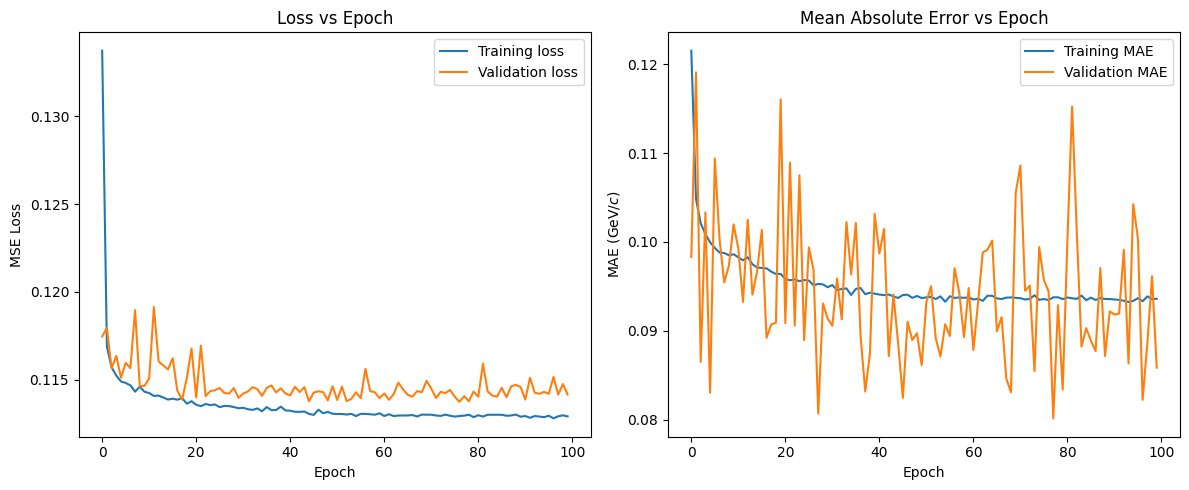

Saved csv_training_history.png
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1s 146us/step


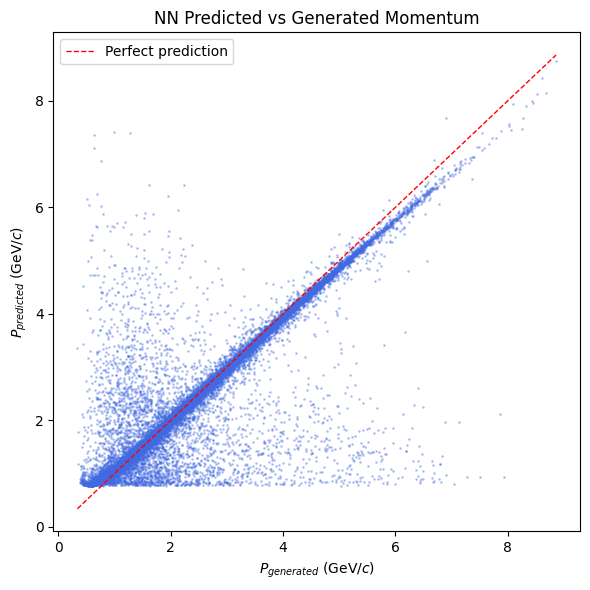

Saved csv_predicted_vs_generated.png


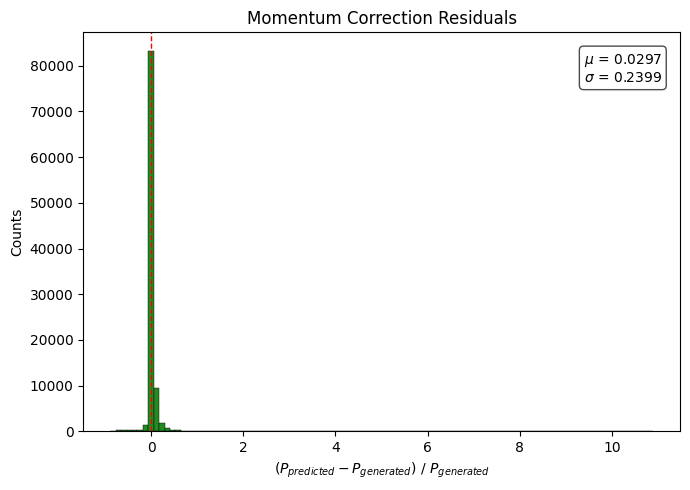

Saved csv_nn_residuals.png


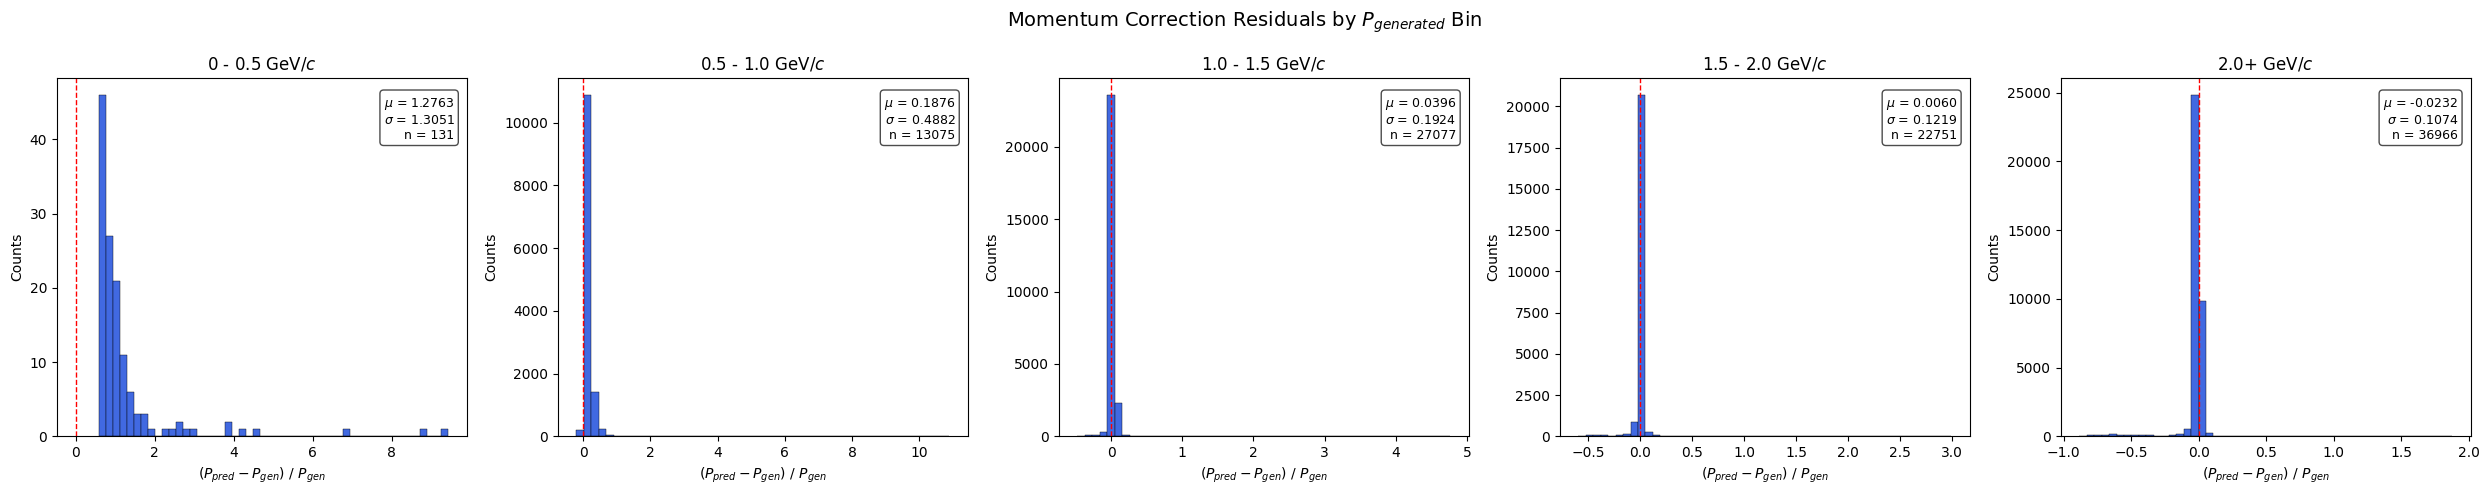

Saved csv_nn_residuals_binned.png


In [3]:
#file parsing
CSV_URL = 'https://userweb.jlab.org/~kenjo/protons_DIS_simul_500K_evnts.csv'

def parse_csv(url):
    p_proton_gen = []
    p_proton_rec = []
    phi_rec      = []
    theta_rec    = []
    skipped = 0

    with urllib.request.urlopen(url) as response:
        #decode bytes to string and read line by line
        lines = response.read().decode('utf-8').splitlines()

    reader = csv.DictReader(lines)

    for row in reader:
        try:
            pg = float(row['p_proton_gen'])
            pr  = float(row['p_proton_rec'])
            phi = float(row['Phi_rec'])
            th  = float(row['Theta_rec'])
            if pr <= 0 or pg <= 0:
                skipped += 1
                continue

            p_proton_gen.append(pg)
            p_proton_rec.append(pr)
            phi_rec.append(phi)
            theta_rec.append(th)

        except (ValueError, KeyError) as e:
            skipped += 1
            continue

    print(f"Events loaded  : {len(p_proton_gen)}")
    print(f"Events skipped : {skipped}")

    return p_proton_gen, p_proton_rec, phi_rec, theta_rec


#load data
p_proton_gen, p_proton_rec, phi_rec, theta_rec = parse_csv(CSV_URL)

#check parser
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Loaded Data Distributions', fontsize=14)

axes[0].hist(p_proton_gen, bins=100, color='royalblue',
             edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('$P_{generated}$ (GeV/$c$)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Generated Proton Momentum')

axes[1].hist(p_proton_rec, bins=100, color='darkorange',
             edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('$P_{reconstructed}$ (GeV/$c$)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Reconstructed Proton Momentum')

axes[2].hist(theta_rec, bins=100, color='forestgreen',
             edgecolor='black', linewidth=0.3)
axes[2].set_xlabel('$\\theta$ (degrees)')
axes[2].set_ylabel('Counts')
axes[2].set_title('Reconstructed $\\theta$')

axes[3].hist(phi_rec, bins=100, color='darkorchid',
             edgecolor='black', linewidth=0.3)
axes[3].set_xlabel('$\\phi$ (degrees)')
axes[3].set_ylabel('Counts')
axes[3].set_title('Reconstructed $\\phi$')

plt.tight_layout()
plt.savefig('csv_input_distributions.png', dpi=150)
plt.show()
print("Saved csv_input_distributions.png")

#plot the correction we will see
delta_p = [pg - pr for pg, pr in zip(p_proton_gen, p_proton_rec)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(p_proton_gen, delta_p, s=1, alpha=0.3, color='steelblue')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$\\Delta P = P_{gen} - P_{rec}$ (GeV/$c$)')
ax.set_title('Momentum Difference vs Generated Momentum')
plt.tight_layout()
plt.savefig('csv_delta_p.png', dpi=150)
plt.show()
print("Saved csv_delta_p.png")

#create inputs
X = np.column_stack([
    p_proton_rec,
    phi_rec,
    theta_rec,
])

y = np.array(p_proton_gen)

print(f"\nInput shape  : {X.shape}")
print(f"Target shape : {y.shape}")

#normalize and split into sets for training/testing
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std

print(f"\nInput means : {X_mean}")
print(f"Input stds  : {X_std}")

X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")

#create NN
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_model(input_dim=3)
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
)

#NN evaluation
#training/testing loss
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['loss'],     label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (GeV/$c$)')
axes[1].set_title('Mean Absolute Error vs Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('csv_training_history.png', dpi=150)
plt.show()
print("Saved csv_training_history.png")

#predicted vs generated
y_pred = model.predict(X_val).flatten()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, y_pred, s=1, alpha=0.3, color='royalblue')
lims = [min(y_val.min(), y_pred.min()),
        max(y_val.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.0, label='Perfect prediction')
ax.set_xlabel('$P_{generated}$ (GeV/$c$)')
ax.set_ylabel('$P_{predicted}$ (GeV/$c$)')
ax.set_title('NN Predicted vs Generated Momentum')
ax.legend()
plt.tight_layout()
plt.savefig('csv_predicted_vs_generated.png', dpi=150)
plt.show()
print("Saved csv_predicted_vs_generated.png")

#residuals
residuals = (y_pred - y_val) / y_val

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=100, color='forestgreen',
        edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.0)
ax.set_xlabel('$(P_{predicted} - P_{generated}) \\ / \\ P_{generated}$')
ax.set_ylabel('Counts')
ax.set_title('Momentum Correction Residuals')
mean_res = np.mean(residuals)
std_res  = np.std(residuals)
ax.text(0.97, 0.95, f'$\\mu$ = {mean_res:.4f}\n$\\sigma$ = {std_res:.4f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig('csv_nn_residuals.png', dpi=150)
plt.show()
print("Saved csv_nn_residuals.png")

#residuals for momentum bins
momentum_bins = [
    (0.0,  0.5,  '0 - 0.5 GeV/$c$'),
    (0.5,  1.0,  '0.5 - 1.0 GeV/$c$'),
    (1.0,  1.5,  '1.0 - 1.5 GeV/$c$'),
    (1.5,  2.0,  '1.5 - 2.0 GeV/$c$'),
    (2.0,  None, '2.0+ GeV/$c$'),
]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Momentum Correction Residuals by $P_{generated}$ Bin', fontsize=14)

for ax, (p_low, p_high, label) in zip(axes, momentum_bins):

    if p_high is None:
        mask = y_val >= p_low
    else:
        mask = (y_val >= p_low) & (y_val < p_high)

    res_bin = residuals[mask]

    if len(res_bin) == 0:
        ax.set_title(f'{label}\n(no entries)')
        ax.set_xlabel('$(P_{pred} - P_{gen}) / P_{gen}$')
        ax.set_ylabel('Counts')
        continue

    ax.hist(res_bin, bins=50, color='royalblue',
            edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.0)
    ax.set_xlabel('$(P_{pred} - P_{gen}) \\ / \\ P_{gen}$')
    ax.set_ylabel('Counts')
    ax.set_title(label)

    mean_b = np.mean(res_bin)
    std_b  = np.std(res_bin)
    ax.text(0.97, 0.95,
            f'$\\mu$ = {mean_b:.4f}\n$\\sigma$ = {std_b:.4f}\nn = {len(res_bin)}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('csv_nn_residuals_binned.png', dpi=150)
plt.show()
print("Saved csv_nn_residuals_binned.png")